<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 128)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.65e-05 | train loss 1.2607 acc 0.579 | val loss 0.9491 acc 0.677 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.65e-05 | train loss 0.8426 acc 0.689 | val loss 0.6469 acc 0.752 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.65e-05 | train loss 0.5744 acc 0.760 | val loss 0.5904 acc 0.769 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.65e-05 | train loss 0.4761 acc 0.787 | val loss 0.5199 acc 0.793 *


...

[ConvNeXt-Tiny] Epoch  21/100 | LR: 5.65e-06 | train loss 0.0730 acc 0.963 | val loss 0.3645 acc 0.877


[ConvNeXt-Tiny] Epoch  22/100 | LR: 5.65e-06 | train loss 0.0551 acc 0.982 | val loss 0.3486 acc 0.882


[ConvNeXt-Tiny] Epoch  23/100 | LR: 5.65e-06 | train loss 0.0499 acc 0.978 | val loss 0.3466 acc 0.882


[ConvNeXt-Tiny] Epoch  24/100 | LR: 5.65e-06 | train loss 0.0501 acc 0.980 | val loss 0.3468 acc 0.884


[ConvNeXt-Tiny] Epoch  25/100 | LR: 5.65e-06 | train loss 0.0433 acc 0.983 | val loss 0.3473 acc 0.887

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 25.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.2885)


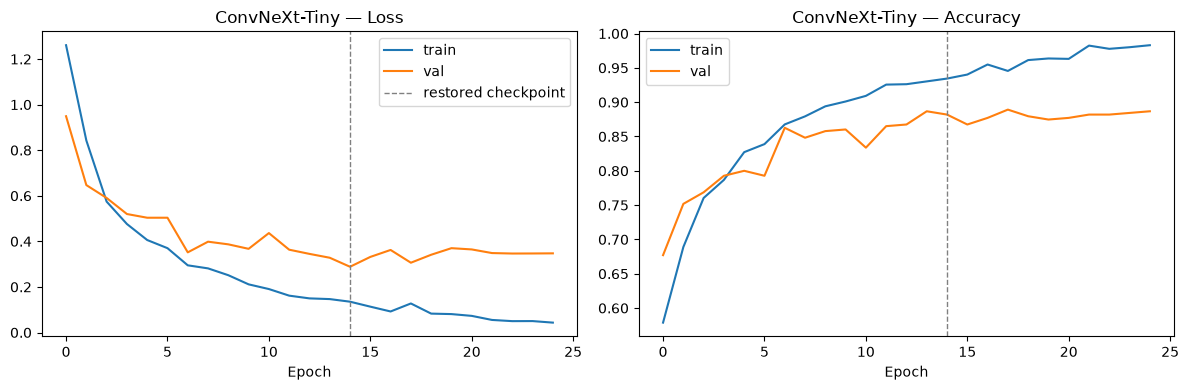

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.901


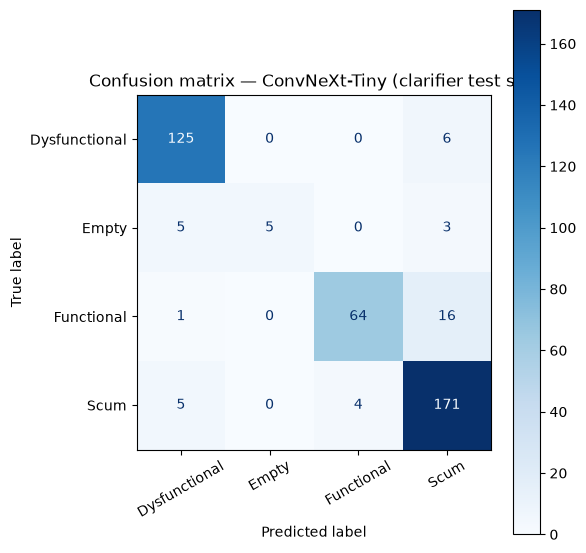

               precision    recall  f1-score   support

Dysfunctional      0.919     0.954     0.936       131
        Empty      1.000     0.385     0.556        13
   Functional      0.941     0.790     0.859        81
         Scum      0.872     0.950     0.910       180

     accuracy                          0.901       405
    macro avg      0.933     0.770     0.815       405
 weighted avg      0.905     0.901     0.897       405



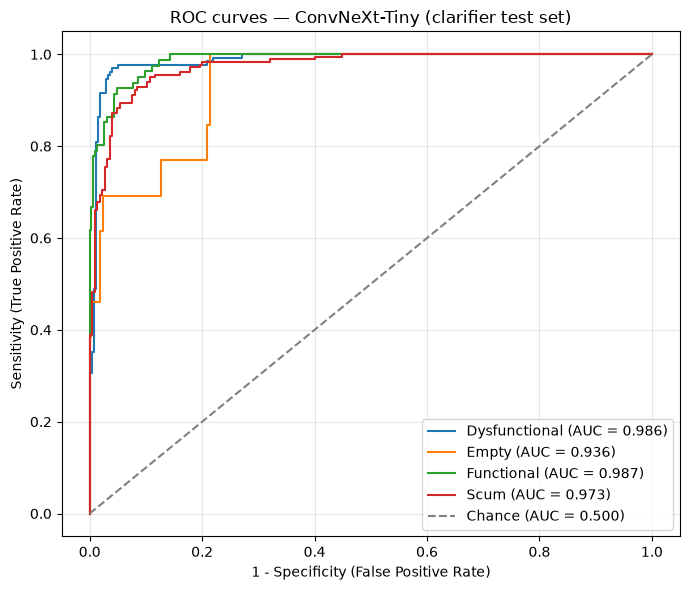

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.986
  Empty          : 0.936
  Functional     : 0.987
  Scum           : 0.973

Mean AUC (over 4/4 classes with test examples): 0.971


(np.float64(0.9012345679012346),
 {'Dysfunctional': 0.9861258148994261,
  'Empty': 0.9364207221350079,
  'Functional': 0.9866636183508611,
  'Scum': 0.9733333333333334})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/clarifier_aug/results_clarifier_convnext_tiny_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
